In [1]:
import pandas as pd
from io import StringIO

data = """Age,MonthlyCharges,Income,Contract,Tenure,Churn
25,49.85,32000,Month-to-month,2,Yes
34,65.40,45000,One year,18,No
42,,58000,Two year,36,No
29,72.10,,Month-to-month,5,Yes
51,89.75,72000,Two year,48,No
38,61.20,51000,,14,Yes
45,95.60,68000,Two year,52,No
27,,35000,Month-to-month,3,Yes
33,54.30,,One year,12,No
60,105.40,92000,Two year,60,No
41,78.90,61000,Month-to-month,,Yes
36,67.50,49000,One year,24,No
48,,75000,Two year,44,No
23,45.20,,Month-to-month,1,Yes
55,110.80,88000,Two year,55,No
31,59.40,42000,,8,Yes
39,73.25,54000,One year,20,No
44,,63000,Month-to-month,16,Yes
28,51.70,,One year,10,No
67,118.90,105000,Two year,62,No
"""

df = pd.read_csv(StringIO(data))

df

,Age,MonthlyCharges,Income,Contract,Tenure,Churn
0,25,49.85,32000.0,Month-to-month,2.0,Yes
1,34,65.40,45000.0,One year,18.0,No
2,42,NaN,58000.0,Two year,36.0,No
3,29,72.10,NaN,Month-to-month,5.0,Yes
4,51,89.75,72000.0,Two year,48.0,No
5,38,61.20,51000.0,NaN,14.0,Yes
6,45,95.60,68000.0,Two year,52.0,No
7,27,NaN,35000.0,Month-to-month,3.0,Yes
8,33,54.30,NaN,One year,12.0,No
9,60,105.40,92000.0,Two year,60.0,No


In [2]:
#finding the missing values 
missing = df.isnull().sum()
#There are 4 features with the missing values monthlycharges , income , contract , tenure 
#missing percentage
percentage_missing = df.isnull().mean() * 100
percentage_missing
#missing rows 
missing_rows = df[df.isnull().any(axis = 1)]
missing_rows
missing

Age               0
MonthlyCharges    4
Income            4
Contract          2
Tenure            1
Churn             0
dtype: int64

In [3]:
df.shape

(20, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             20 non-null     int64  
 1   MonthlyCharges  16 non-null     float64
 2   Income          16 non-null     float64
 3   Contract        18 non-null     object 
 4   Tenure          19 non-null     float64
 5   Churn           20 non-null     object 
dtypes: float64(3), int64(1), object(2)
memory usage: 1.1+ KB


In [5]:
df.describe()

,Age,MonthlyCharges,Income,Tenure
count,20.000000,16.000000,16.000000,19.000000
mean,39.800000,74.953125,61875.000000,25.789474
std,11.963101,22.913944,20687.758055,21.306178
min,23.000000,45.200000,32000.000000,1.000000
25%,30.500000,58.125000,48000.000000,9.000000
50%,38.500000,69.800000,59500.000000,18.000000
75%,45.750000,91.212500,72750.000000,46.000000
max,67.000000,118.900000,105000.000000,62.000000


In [22]:
mean_median_df = pd.DataFrame({"Column" :['Age' , "MonthlyCharges","Income" , "Tenure"], 'Mean' : [df['Age'].mean() , df['MonthlyCharges'].mean() , df['Income'].mean(), df['Tenure'].mean()] , 'Median' : [df['Age'].median() , df['MonthlyCharges'].median() , df['Income'].median() , df['Tenure'].median()]})
mean_median_df

,Column,Mean,Median
0,Age,39.800000,38.5
1,MonthlyCharges,74.953125,69.8
2,Income,61875.000000,59500.0
3,Tenure,25.789474,18.0


In [7]:
# Age : Mean  becuase As i inpect the age feature i does not found any mislead , that why i am replacing the missing values with the mean value of the age becuase mean is the best value for replacing in this case
# MonthlyCharges : Mean same reson of age
# income : Median becuase it is include outlier and median is not effected by the outlier
# contract : Unknown becuase it can store some important information 
# tenure : Remove that one row

<Axes: >

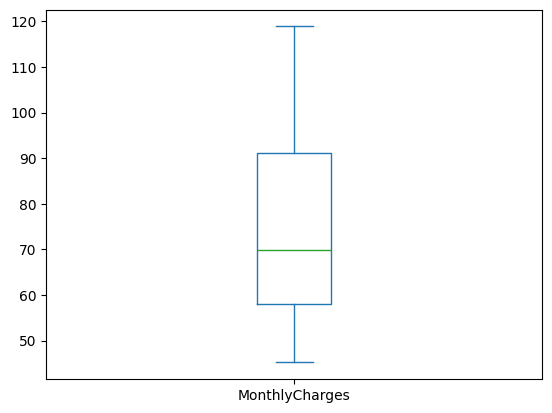

In [8]:
df["MonthlyCharges"].plot(kind="box")

In [9]:
df.isnull().sum()

Age               0
MonthlyCharges    4
Income            4
Contract          2
Tenure            1
Churn             0
dtype: int64

In [10]:
df.isna().mean() * 100

Age                0.0
MonthlyCharges    20.0
Income            20.0
Contract          10.0
Tenure             5.0
Churn              0.0
dtype: float64

In [17]:
numeric = df.select_dtypes(include = 'number')
categorical = df.select_dtypes(include = ['object'])

In [21]:
MonthlyCharges_missing = df['MonthlyCharges'].isnull().astype(int)
Income_missing = df['Income'].isnull().astype(int)
Contract_missing = df['Contract'].isnull().astype(int)
Tenure_missing = df['Tenure'].isnull().astype(int)

In [23]:
df.head()

,Age,MonthlyCharges,Income,Contract,Tenure,Churn
0,25,49.85,32000.0,Month-to-month,2.0,Yes
1,34,65.40,45000.0,One year,18.0,No
2,42,NaN,58000.0,Two year,36.0,No
3,29,72.10,NaN,Month-to-month,5.0,Yes
4,51,89.75,72000.0,Two year,48.0,No


In [30]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = 'Churn')
y = df["Churn"]
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state = 42 , test_size = 0.2)
income_median = X_train['Income'].median()
X_train['Income'] = X_train['Income'].fillna(income_median)
X_test['Income'] = X_test['Income'].fillna(income_median)
